<a href="https://colab.research.google.com/github/markpy18/Atividades_Inteligencia_Artificial/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Índice

1. [🔗 Importação de Bibliotecas](#Bibliotecas)
2. [🔗 Carga e Configuração dos Dados](#Carregando-os-dados-do-dataset-e-configurando-os-gr%C3%A1ficos.)
3. [🔗 Análise de Z-Score](#Aplicando-o-Z-Score:)
4. [🔗 Distribuição Binomial](#Agora-fazendo-a-distribui%C3%A7%C3%A3o-binomial,-considerando-o-comprimento-da-s%C3%A9pala-sendo-maior-que-6.0-cm.)
5. [🔗 Distribuição de uma Amostra Única](#Distribui%C3%A7%C3%A3o-da-amostra,-considerando-1-amostra-de-n-amostras.)
6. [🔗 Teorema do Limite Central (TLC)](#Aplicando-o-sampling-distribuition-e-o-TLC(Teorema-do-limite-central))

# Apresentação:

Nome: Marcos Eduardo Rodrigues Macedo

Curso: Inteligência Artificial

Nesta atividade vamos aplicar ao dataset de Íris na prática o Z-Score, a Distribuição Binomial, Distribuição da amostra(sample distribution) e a distribuição da amostragem e a teoria do limite central.

# Bibliotecas

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binom, norm
from sklearn.datasets import load_iris

Carregando os dados do dataset e configurando os gráficos.

In [93]:
# Configuração do estilo dos gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Carregar o Dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
col = 'sepal length (cm)'
x = df[col]

Aplicando o Z-Score:

In [94]:
# --- CÁLCULO DO Z-SCORE ---
mu = x.mean()
sigma = x.std(ddof=0)
df['z_score'] = (x - mu) / sigma

print(f'Média Populacional (μ): {mu:.2f} cm')
print(f'Desvio-Padrão (σ): {sigma:.2f} cm')
print('\nExemplo das primeiras flores com Z-Score:')
print(df[[col, 'z_score']].head())

Média Populacional (μ): 5.84 cm
Desvio-Padrão (σ): 0.83 cm

Exemplo das primeiras flores com Z-Score:
   sepal length (cm)   z_score
0                5.1 -0.900681
1                4.9 -1.143017
2                4.7 -1.385353
3                4.6 -1.506521
4                5.0 -1.021849


Aplicando no gráfico:

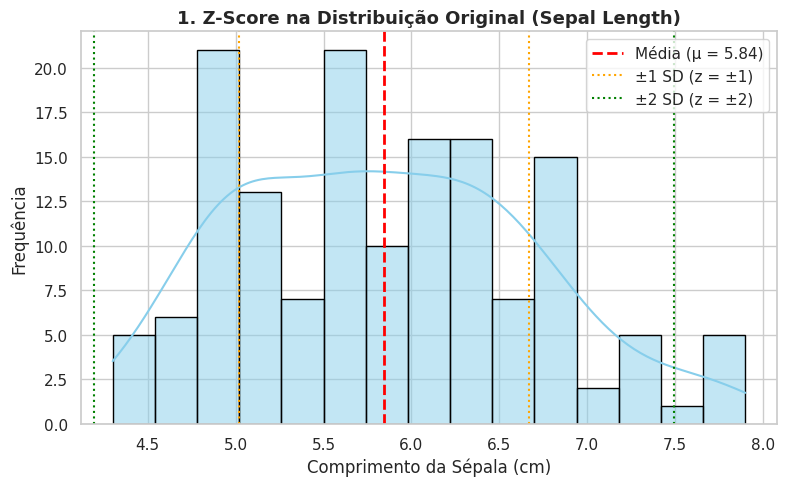

In [95]:
# --- GRÁFICO DO Z-SCORE ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(x, kde=True, ax=ax, color='skyblue', edgecolor='black', bins=15)

ax.axvline(
    mu, color='red', linestyle='--', linewidth=2, label=f'Média (μ = {mu:.2f})'
)
ax.axvline(
    mu + sigma,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label='±1 SD (z = ±1)',
)
ax.axvline(mu - sigma, color='orange', linestyle=':', linewidth=1.5)
ax.axvline(
    mu + 2 * sigma,
    color='green',
    linestyle=':',
    linewidth=1.5,
    label='±2 SD (z = ±2)',
)
ax.axvline(mu - 2 * sigma, color='green', linestyle=':', linewidth=1.5)

ax.set_title(
    '1. Z-Score na Distribuição Original (Sepal Length)',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('Comprimento da Sépala (cm)')
ax.set_ylabel('Frequência')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Agora fazendo a distribuição binomial, considerando o comprimento da sépala sendo maior que 6.0 cm.

In [96]:
# --- CÁLCULO DA BINOMIAL ---
# Regra: Sucesso = Sépala > 6.0 cm
p = (x > 6.0).mean()  # Probabilidade de sucesso (~0.4067)
n = 10  # Tamanho do experimento
k_alvo = 4  # Queremos calcular a chance de ter exatamente 4 sucessos

prob_k4 = binom.pmf(k_alvo, n, p)
print(f'Probabilidade P(X={k_alvo}) em {n} flores: {prob_k4:.2%}')

Probabilidade P(X=4) em 10 flores: 25.06%


Gráfico:

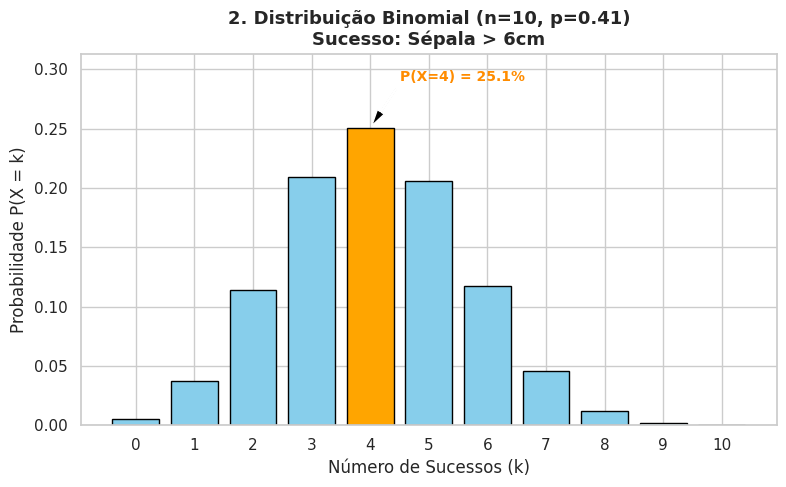

In [97]:
# --- GRÁFICO DA BINOMIAL ---
fig, ax = plt.subplots(figsize=(8, 5))
k_vals = np.arange(0, n + 1)
probs = binom.pmf(k_vals, n, p)

colors = ['orange' if k == k_alvo else 'skyblue' for k in k_vals]
ax.bar(k_vals, probs, color=colors, edgecolor='black')

ax.set_title(
    f'2. Distribuição Binomial (n={n}, p={p:.2f})\nSucesso: Sépala > 6cm',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('Número de Sucessos (k)')
ax.set_ylabel('Probabilidade P(X = k)')
ax.set_xticks(k_vals)

# Destaque na barra de interesse (k=4)
ax.annotate(
    f'P(X={k_alvo}) = {prob_k4:.1%}',
    xy=(k_alvo, prob_k4),
    xytext=(k_alvo + 0.5, prob_k4 + 0.04),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold',
    color='darkorange',
)
ax.set_ylim(0, max(probs) * 1.25)
plt.tight_layout()
plt.show()

Distribuição da amostra, considerando 1 amostra de n amostras.

In [98]:
# --- RETIRANDO UMA ÚNICA AMOSTRA ---
amostra_30 = x.sample(n=30, random_state=42)

print(f'Média da População: {mu:.2f} cm')
print(f'Média de UMA Amostra (n=30): {amostra_30.mean():.2f} cm')

Média da População: 5.84 cm
Média de UMA Amostra (n=30): 5.98 cm


Agora vemos a aplicação no gráfico comparativo

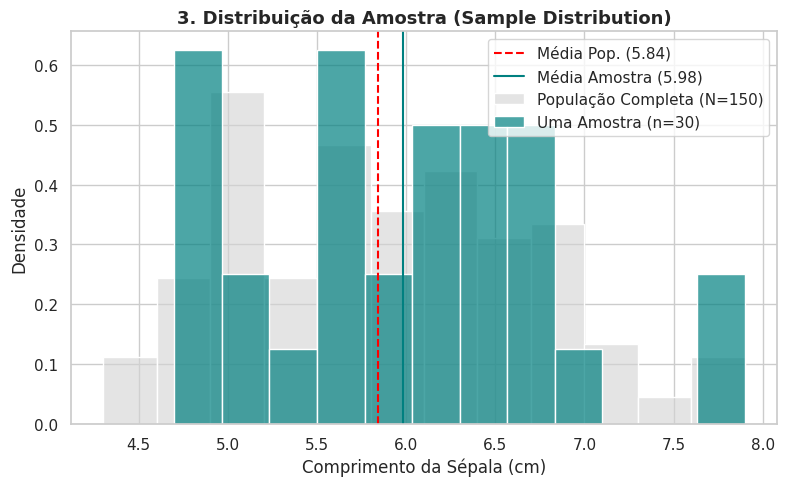

In [99]:
# --- GRÁFICO COMPARATIVO ---
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x,
    color='lightgray',
    label='População Completa (N=150)',
    ax=ax,
    stat='density',
    bins=12,
    alpha=0.6,
)
sns.histplot(
    amostra_30,
    color='teal',
    label='Uma Amostra (n=30)',
    ax=ax,
    stat='density',
    bins=12,
    alpha=0.7,
)

ax.axvline(mu, color='red', linestyle='--', label=f'Média Pop. ({mu:.2f})')
ax.axvline(
    amostra_30.mean(),
    color='teal',
    linestyle='-',
    label=f'Média Amostra ({amostra_30.mean():.2f})',
)

ax.set_title(
    '3. Distribuição da Amostra (Sample Distribution)',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('Comprimento da Sépala (cm)')
ax.set_ylabel('Densidade')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Aplicando o sampling distribuition e o TLC(Teorema do limite central)

In [100]:
# --- SIMULAÇÃO DE 1.000 AMOSTRAS (Sampling Distribution) ---
np.random.seed(42)
medias_amostrais = [x.sample(n=30, replace=True).mean() for _ in range(1000)]

mean_means = np.mean(medias_amostrais)
se_theo = sigma / np.sqrt(30)
se_emp = np.std(medias_amostrais)

print(f'Média das 1.000 Médias: {mean_means:.4f} cm (Média Pop: {mu:.4f} cm)')
print(f'Erro Padrão Teórico: {se_theo:.4f}')
print(f'Erro Padrão Empírico: {se_emp:.4f}')

Média das 1.000 Médias: 5.8525 cm (Média Pop: 5.8433 cm)
Erro Padrão Teórico: 0.1507
Erro Padrão Empírico: 0.1509


Agora veremos isso aplicado na prática no gráfico:

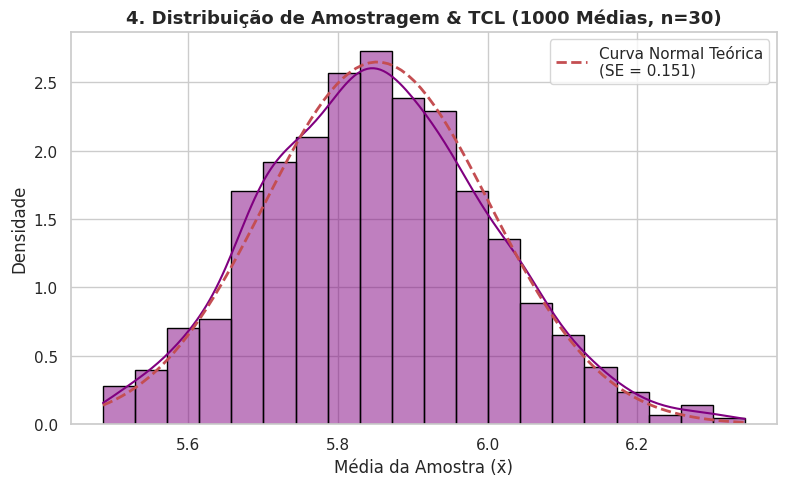

In [101]:
# --- GRÁFICO DO TCL ---
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    medias_amostrais,
    kde=True,
    ax=ax,
    color='purple',
    stat='density',
    bins=20,
    edgecolor='black',
    alpha=0.5,
)

# Ajuste da Curva Normal Teórica
x_axis = np.linspace(min(medias_amostrais), max(medias_amostrais), 100)
ax.plot(
    x_axis,
    norm.pdf(x_axis, mean_means, se_theo),
    'r--',
    linewidth=2,
    label=f'Curva Normal Teórica\n(SE = {se_theo:.3f})',
)

ax.set_title(
    '4. Distribuição de Amostragem & TCL (1000 Médias, n=30)',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('Média da Amostra (x̄)')
ax.set_ylabel('Densidade')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()